 <center> <h1> Introducción - Seaborn </h1></center>
    
- Docente: Edwin Jahir Rueda Rojas
- Email: edruedaro@uide.edu.ec

[Seaborn](https://seaborn.pydata.org/) es una librería de visualización en python basada en [matplotlib](https://matplotlib.org/) e integrada ampliamente con [pandas](https://pandas.pydata.org/pandas-docs/stable/index.html). Básicamente es una capa superior a matplotlib la cual ya cuenta con una interfaz gráfica mas atractiva por defecto (los llamados [temas](https://seaborn.pydata.org/tutorial/aesthetics.html) y [paletas de colores](https://seaborn.pydata.org/tutorial/color_palettes.html))

In [ ]:
!pip install seaborn

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme()

Text(0.5, 1.0, 'Simple Plot using pyplot-style')

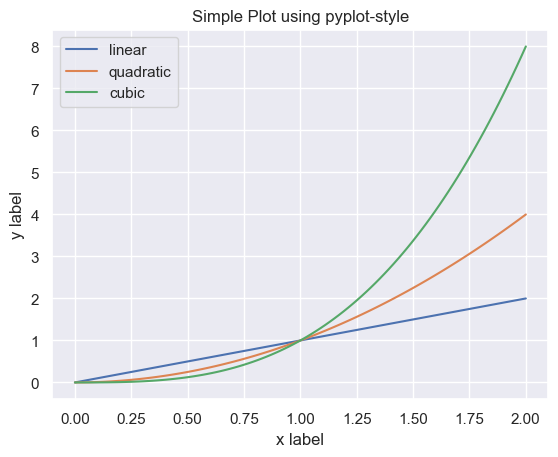

In [27]:
x = np.linspace(0,2,100)

### code here ###
sns.lineplot(x=x, y=x, label='linear')
sns.lineplot(x=x, y=x**2, label='quadratic')
sns.lineplot(x=x, y=x**3, label='cubic')
plt.xlabel('x label')
plt.ylabel('y label')
plt.title("Simple Plot using pyplot-style")

La ventaja de seaborn es que se integra muy bien con pandas, agregando mas información a nuestro gráfico:

In [28]:
np.random.seed(6)
metros_cuadrados = np.random.randint(50, 150, size=10)
habitaciones = np.random.randint(1, 5, size=10)
precio = metros_cuadrados * np.random.randint(800, 1500, size=10)

df = pd.DataFrame({
    "metro_cuadrado": metros_cuadrados,
    "numero_habitaciones": habitaciones,
    "precio": precio
})

df.head()

,metro_cuadrado,numero_habitaciones,precio
0,60,2,55800
1,123,2,123492
2,149,3,123819
3,134,4,167500
4,129,2,185373


Text(0.5, 0, '$m^2$')

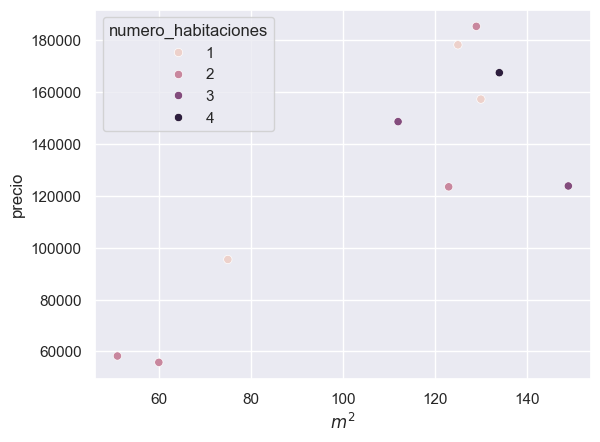

In [29]:
sns.scatterplot(data=df, x="metro_cuadrado", y="precio", hue="numero_habitaciones")
plt.xlabel("$m^2$")

<h3>Tipos de gráficos</h3>

Seaborn ofrece una capa mas abstracta de gráficos, los cuales se pueden dividir en tres categorias: relacionales, distribución, categoricos.
<img src="./images/seaborn_plots.png" width="80%">

Exploremos [`sns.scatterplot(**args)`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html#seaborn-scatterplot)
- [datasets](https://github.com/mwaskom/seaborn-data)

In [30]:
tips = sns.load_dataset("tips")
print(f"Dimensión del dataset: {tips.shape}")
tips.head()

Dimensión del dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

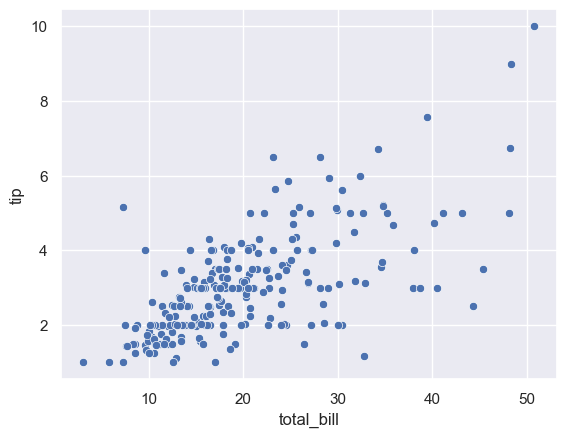

In [31]:
## code here ##
sns.scatterplot(data=tips, x="total_bill", y="tip")

Podemos facilmente generar otras relaciones mediante el parámetro `hue`

<Axes: xlabel='total_bill', ylabel='tip'>

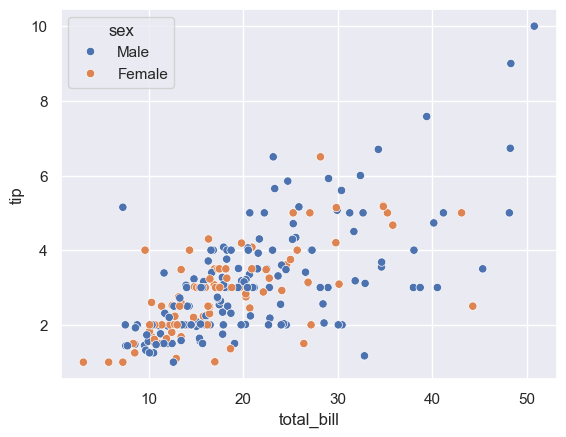

In [33]:
## code here ###
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex")

También podemos modificar/ajustar nuestro gráfico con el parámetro `style`:

<Axes: xlabel='total_bill', ylabel='tip'>

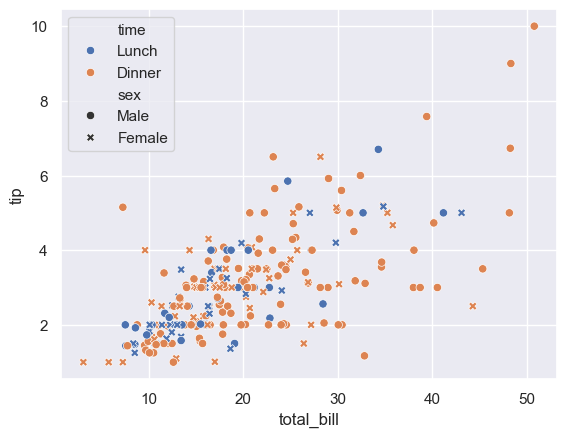

In [36]:
### code here ###
sns.scatterplot(data=tips, x="total_bill", y="tip", style="sex", hue="time")
#plot.scatter(df[sex=="Male"])
#plot.scatter(df[sex=="Female"])

o `marker`:

<Axes: xlabel='total_bill', ylabel='tip'>

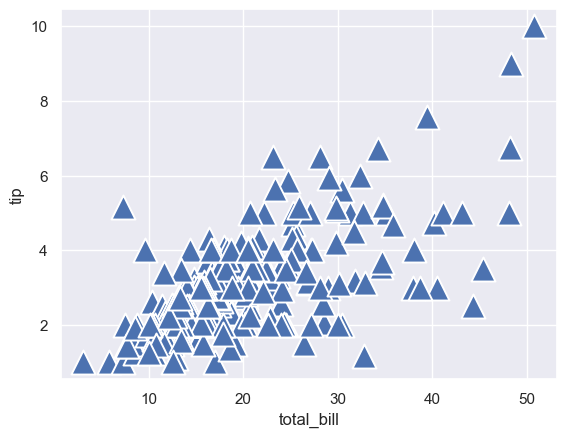

In [42]:
### code here ###
sns.scatterplot(data=tips, x="total_bill", y="tip", marker="^", s=300)

Podemos inclusive crear subplots definidos por columnas de nuestro dataset:

In [43]:
sns.relplot?

Signature:
sns.relplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    size=None,
    style=None,
    units=None,
    weights=None,
    row=None,
    col=None,
    col_wrap=None,
    row_order=None,
    col_order=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    sizes=None,
    size_order=None,
    size_norm=None,
    markers=None,
    dashes=None,
    style_order=None,
    legend='auto',
    kind='scatter',
    height=5,
    aspect=1,
    facet_kws=None,
    **kwargs,
)
Docstring:
Figure-level interface for drawing relational plots onto a FacetGrid.

This function provides access to several different axes-level functions
that show the relationship between two variables with semantic mappings
of subsets. The `kind` parameter selects the underlying axes-level
function to use:

- :func:`scatterplot` (with `kind="scatter"`; the default)
- :func:`lineplot` (with `kind="line"`)

Extra keyword arguments are passed to the underlying function, so you
should re

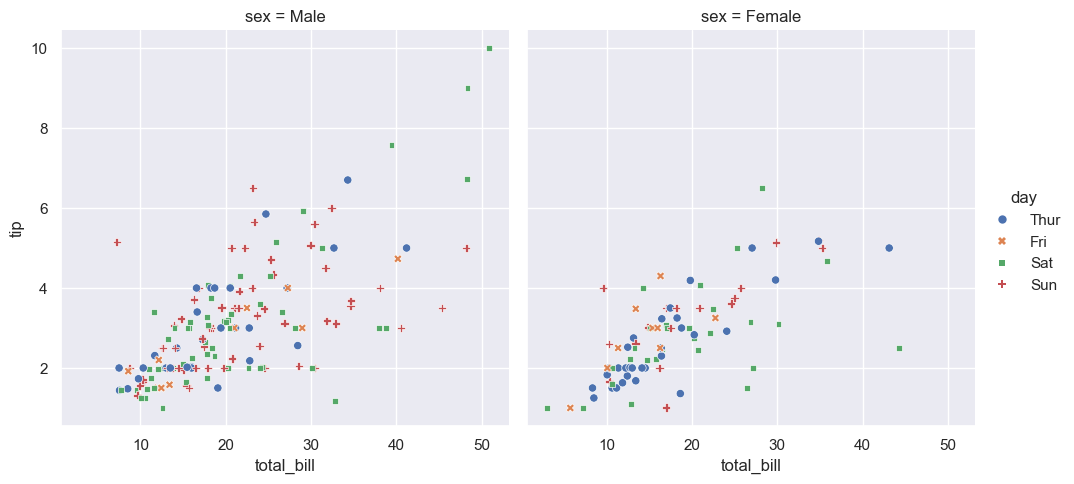

In [44]:
## code here ##
sns.relplot(data=tips, x="total_bill", y="tip", col="sex", hue="day", style="day")

Exploremos [`sns.histplot`](https://seaborn.pydata.org/generated/seaborn.histplot.html)

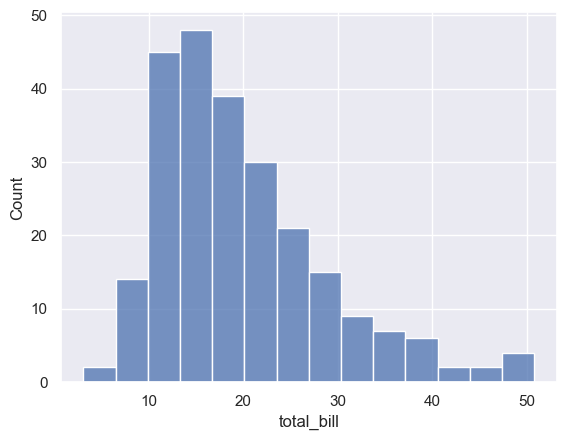

In [45]:
sns.histplot(data=tips, x="total_bill");

o si definimos los datos en el eje $y$

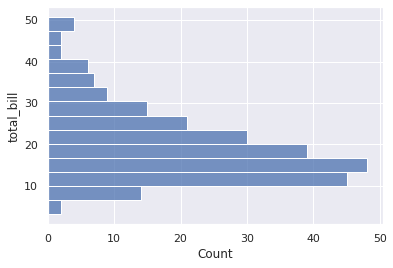

In [53]:
sns.histplot(data=tips, y="total_bill");

podemos agregar características que nos brinda seaborn, tales con el [KDE](https://scikit-learn.org/stable/modules/density.html#density-estimation-histograms):

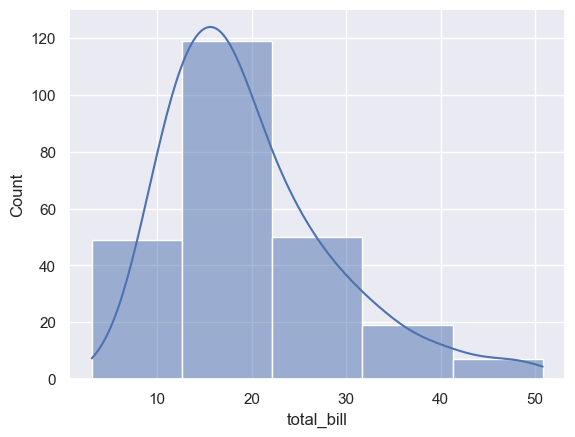

In [48]:
sns.histplot(data=tips, x="total_bill", kde=True, bins=5);

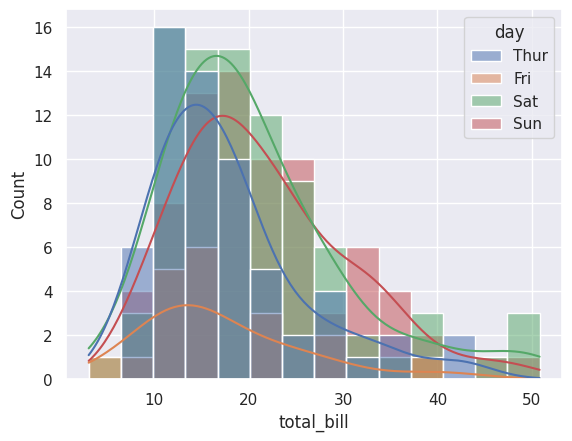

In [38]:
sns.histplot(data=tips, x="total_bill", kde=True, hue="day");

Para que las barras no se sobrepongan, podemos crear un gráfico de barras apilado utilizando la propiedad `multiple`:

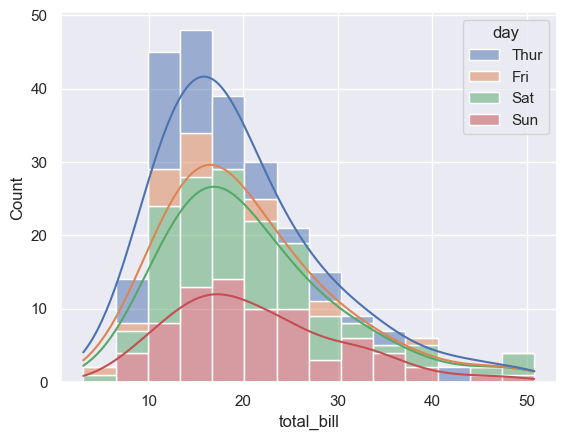

In [49]:
## code here ##
sns.histplot(data=tips, x="total_bill", kde=True, hue="day", multiple="stack");

Exploremos el [`sns.rugplot`](https://seaborn.pydata.org/generated/seaborn.rugplot.html):

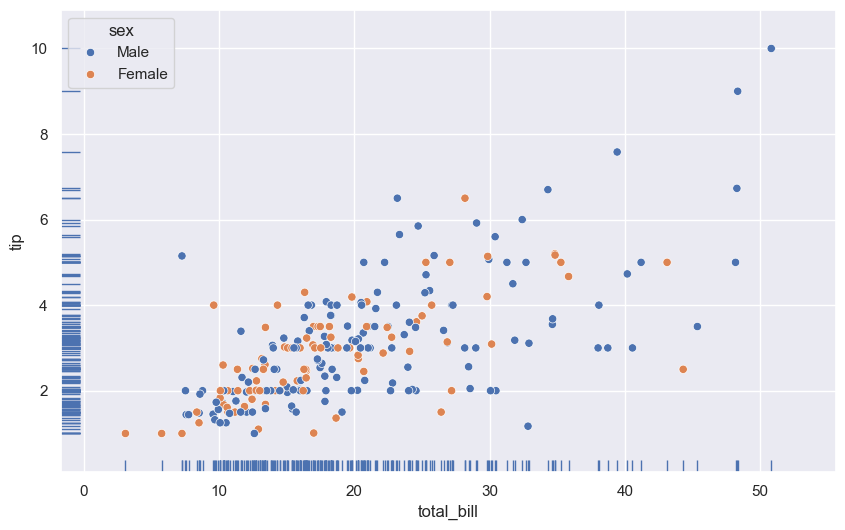

In [50]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex")
sns.rugplot(data=tips, x="total_bill", y="tip");

Exploremos [`sns.stripplot`](https://seaborn.pydata.org/generated/seaborn.stripplot.html) el cual nos permite utilizar el gráfico `scatterplot` con datos categoricos mediante el uso de `jitter`/fluctuación

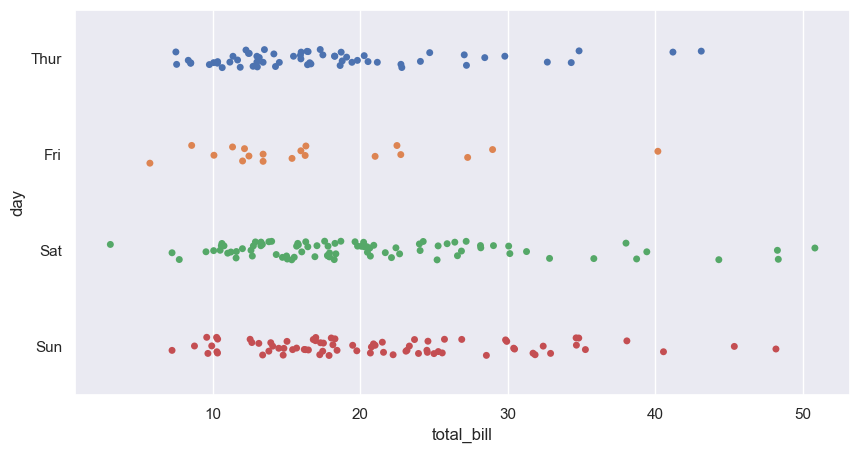

In [51]:
plt.figure(figsize=(10,5))
sns.stripplot(data=tips, x="total_bill", y="day", hue="day");

Desactivemos el uso de `jitter` y notemos como se sobreponen los datos, dando una vista errada de que el conjunto de datos es menor:

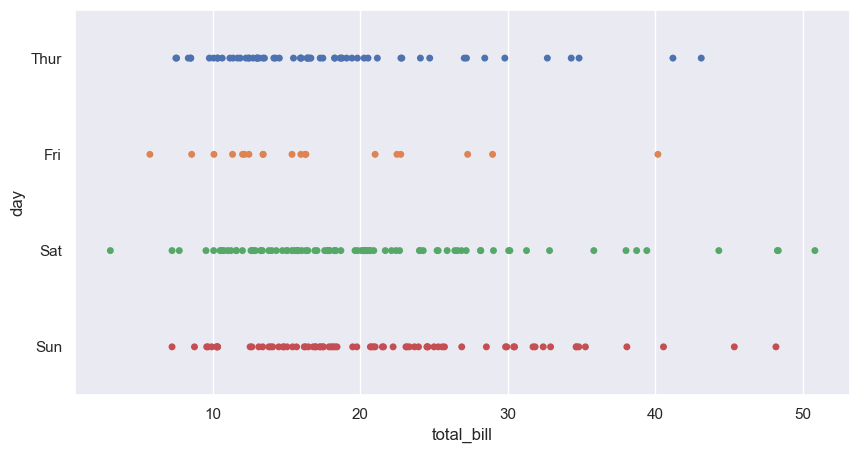

In [15]:
plt.figure(figsize=(10,5))
sns.stripplot(data=tips, x="total_bill", y="day", hue="day", jitter=False);

Otro gráfico útil es el [`swarmplot`](https://seaborn.pydata.org/generated/seaborn.swarmplot.html) el cual permite organizar los datos de tal manera que no se sobrepongan

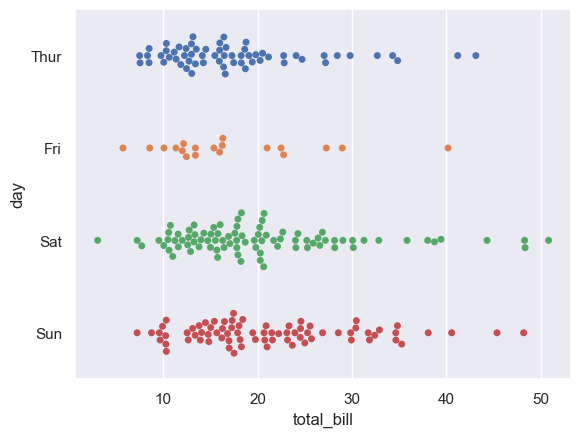

In [52]:
sns.swarmplot(data=tips, x="total_bill", y="day",hue="day");

C:\Users\Windows\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Windows\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


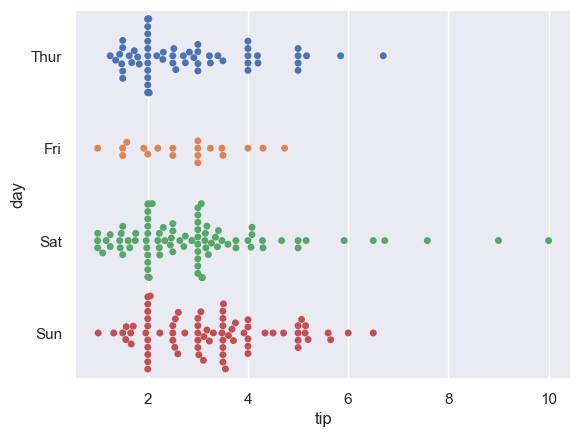

In [53]:
sns.swarmplot(data=tips, x="tip", y="day", hue="day");

Exploremos los gráficos de cajas [`sns.boxplots`](https://seaborn.pydata.org/generated/seaborn.boxplot.html)

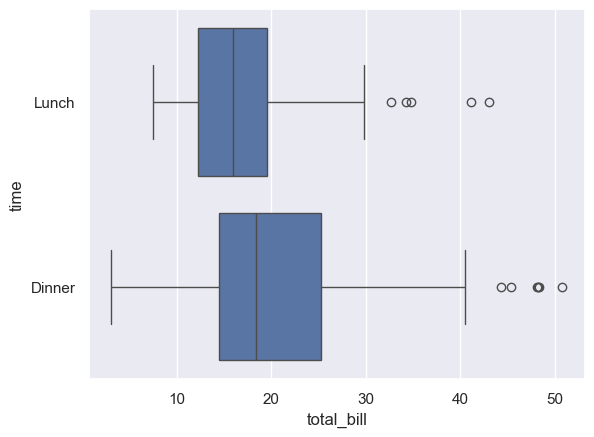

In [54]:
sns.boxplot(
    data=tips, x="total_bill", y="time"
);

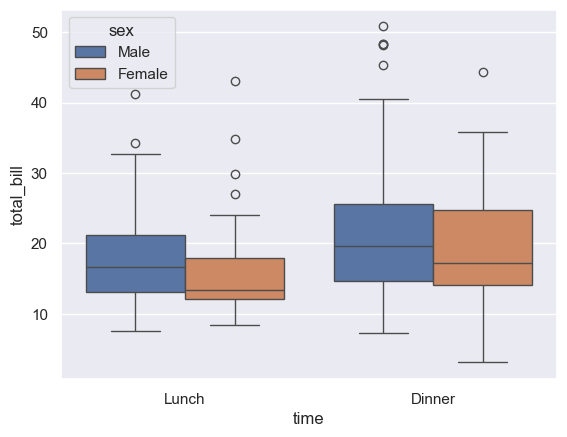

In [19]:
sns.boxplot(
    data=tips, y="total_bill", x="time", hue="sex"
);

o implementar el gráfico [`violinplot`](https://seaborn.pydata.org/generated/seaborn.violinplot.html)

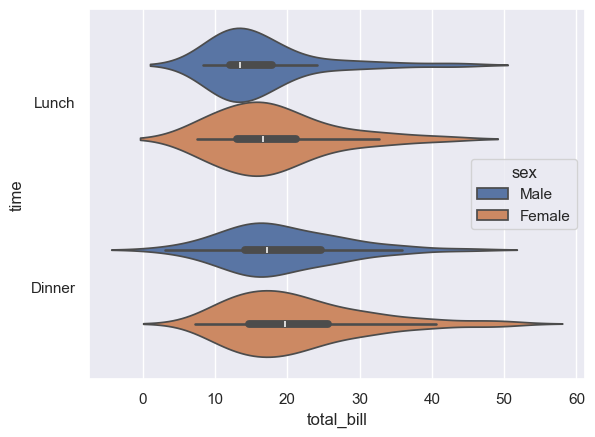

In [20]:
sns.violinplot(
    data=tips, x="total_bill", y="time", hue="sex"
);

Un método rápido de explorar la relación de nuestros datos

In [21]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


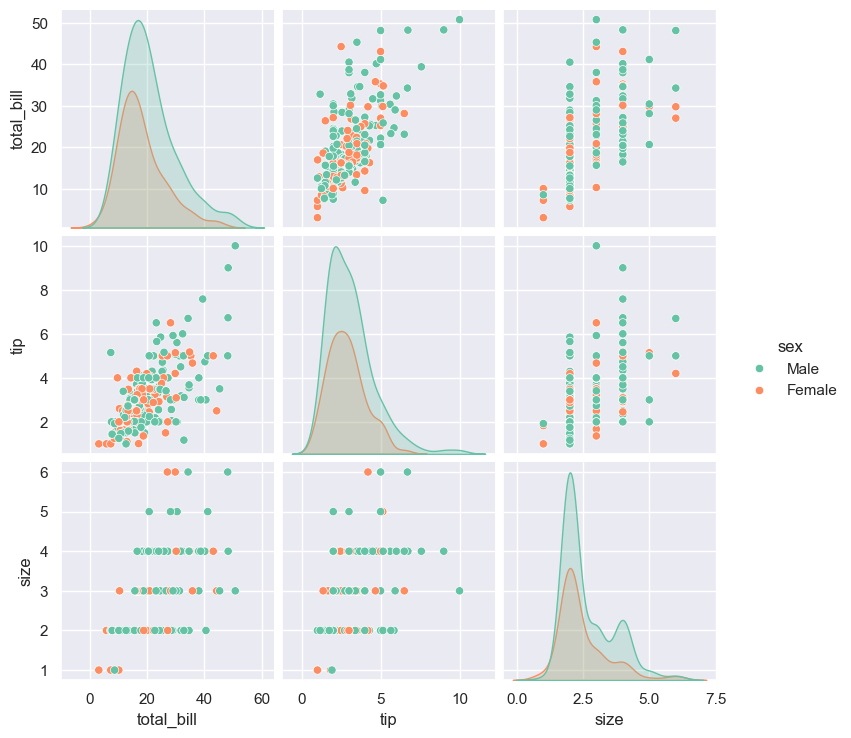

In [57]:
g = sns.pairplot(data=tips, hue="sex", palette="Set2", diag_kind="kde", height=2.5)

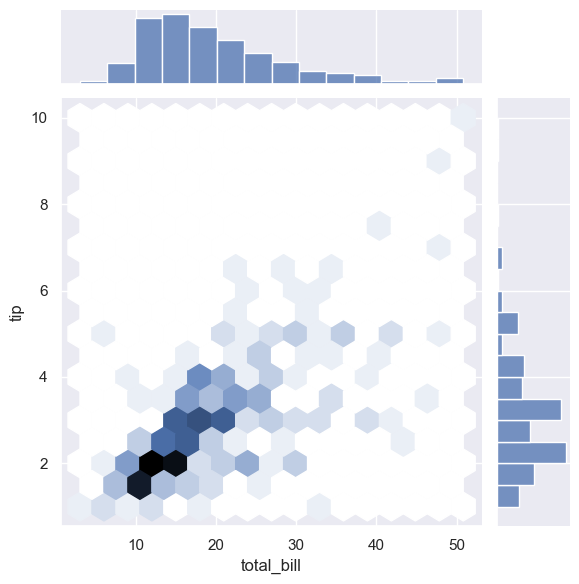

In [60]:
g = sns.jointplot(data=tips, x="total_bill", y="tip", kind="hex")